# Case study E9: Neural Process MPC

*Neural Process Model Predictive Control* (Waibel, Mello Rella, Jones, 2026) swings up a Furuta
pendulum with an MPC whose model is a conditional neural process (CNP). The CNP is meta-trained
across a family of pendulums. At deployment its **encoder** turns a short context trajectory of the
pendulum at hand into a four-number latent code $z$, and its **decoder**, conditioned on $z$, is the
one-step model inside the MPC: it adapts to an unseen pendulum from a few samples, without retraining.

The authors' code ([jowaibel/neural_process_mpc](https://github.com/jowaibel/neural_process_mpc) at
`2d8de66`) has the controller four times: in Python with CasADi's Opti and IPOPT, and in C++ with
CasADi, with laOPT and IPOPT, and with laOPT's SQP and PIQP. It also has an equation-based baseline,
the analytic Furuta model under implicit midpoint, in each. This study runs all of them as published,
then reimplements the encoder, the decoder and both MPCs in Scaly and compares:

- **replay**: every implementation solves the same 100 OCPs from the same starting points, the ones
  the authors' Python controller met over one closed-loop swing-up;
- **lockstep**: whole closed-loop episodes against a deterministic plant, the authors' controller
  loop reproduced step for step, and the adaptation study (three pendulums, four context sizes);
- **real time**: the authors' own simulator server, their clients and a Scaly client.

The Scaly cells below run without PyTorch, CasADi or laOPT. The baseline cells need
`baseline/setup.sh` and are off by default (`RUN_BASELINES`); the recorded results in `results/` are
shown instead. The write-up is `internal/notes/case_study_e9_report.html`.

In [1]:
import json
import subprocess
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

HERE = Path.cwd()
sys.path[:0] = [str(HERE), str(HERE.parent)]

import plotstyle
import protocol as pr
import scaly_impl as si

plotstyle.use()
RUN_BASELINES = False  # True reruns compare.py (about 20 minutes; needs baseline/setup.sh)
RESULTS = HERE / "results"


def load(name: str) -> dict:
  return json.loads((RESULTS / name).read_text())

/Users/cnjones/.local/share/uv/python/cpython-3.14.3-macos-aarch64-none/lib/python3.14/importlib/__init__.py:88: ExperimentalWarning: scaly.nn is experimental (scaly-experimental): it may change or be removed without notice
  return _bootstrap._gcd_import(name[level:], package, level)


## The model

The checkpoint is the authors' `model/model.pth` (vendored with the benchmark problem as
`bench/problems/npmpc/data/cnp_model.pth`, the same bytes). `nn.load_torch_state_dict` reads it
without torch. The encoder maps each context pair $(x_i, y_i)$, with features
$x = (\sin\theta, \cos\theta, \dot\theta, \dot\varphi, u)$ and $y$ the velocity change over one step,
through $7 \to 64 \to 128 \to 128 \to 64 \to 4$ with GELU, and averages. The decoder maps $[x, z]$
through $9 \to 32 \to 32 \to 2$ with sigmoids to the mean velocity change, and the angles advance
by the trapezoid:

$$x_{k+1} = x_k + \big[\,\Delta t\,(\dot\theta_k, \dot\varphi_k) + \tfrac{\Delta t}{2}\,\mu(x_k, u_k; z),\ \mu(x_k, u_k; z)\,\big].$$

GELU is $x\,\Phi(x)$, so the encoder needs `erf`. Scaly has it. (The benchmark problem's README
predates the operation and skips the encoder for that reason.)

In the context experiment the pendulum hangs, takes 100 random torques in $\pm 0.02$ N m, one per
20 ms, and its states are recorded. Here the plant is the analytic Furuta model integrated at 4 kHz,
as the authors' simulator does, and this is system 3 of their adaptation study.

In [2]:
t0 = time.perf_counter()
cnp = si.load_cnp()
encoder = si.encoder_function(cnp)
inputs = pr.context_inputs(seed=0)
states = pr.context_run(pr.SYSTEMS["sys3"], inputs)
z = si.encode(encoder, *pr.context_pairs(states, inputs, 100))
reference = {m: load(f"lockstep_casadi-python-published_{m}.json") for m in ("neural", "equation")}
print(f"z (Scaly)         {np.array2string(z, precision=6)}   ({time.perf_counter() - t0:.2f} s with the encoder's compile)")
print(f"z (their encoder) {np.array2string(np.array(reference['neural']['theta']), precision=6)}")
print(f"largest difference {np.abs(z - reference['neural']['theta']).max():.1e} (their network runs in float32)")

z (Scaly)         [-2.497842  0.086874 -9.795746 -1.668231]   (0.15 s with the encoder's compile)
z (their encoder) [-2.497843  0.086874 -9.795747 -1.668231]
largest difference 1.1e-06 (their network runs in float32)


## Two transcriptions, each mirrored

The authors write the same OCP twice. The CasADi controllers (`MPCController._build_optimization`)
pose every constraint as a row, including the input bounds and a $\pm 10^{-3}$ band around the
measured state, and carry four slacks of which only the arm angle's is used. The laOPT controllers
(`MultipleShootingXDiff` over `FurutaNPOCP`) make the band, the inputs and the slacks variable
bounds and fix the unused slacks at zero. Both have $N = 12$, $\Delta t = 20$ ms, the stage cost
on $2(1-\cos\theta)$, the inter-stage cost on $x_{k+1} - x_k$, an LQR terminal weight from the
Riccati equation of the model linearized at upright, and $|\varphi| \le 2 + s$ with a penalized
slack $s \in [0, 5]$.

`scaly_impl.problem(model, form)` writes both, `form="opti"` and `form="laopt"`. The initial state,
$z$ (or the plant parameters) and the terminal weight are runtime parameters, so one compiled solver
serves every latent code; CasADi's Opti bakes them into its graph.

The Opti mirror has to place constants where Opti places them. Opti turns a side free of variables
into the row's bound ($x_0 \le x_0^{\rm meas} + 10^{-3}$ is the row $x_0$ with upper bound
$x_0^{\rm meas} + 10^{-3}$) and otherwise writes $a \le b$ as $a - b \le 0$. IPOPT pushes its slacks
off a bound by $10^{-2}\max(1, |{\rm bound}|)$, so the same inequality with its constant on the
other side takes different iterates. Written Opti's way, Scaly's IPOPT follows CasADi's iteration
for iteration. Here are the first 20 instances the authors' controller met in its swing-up, replayed
live through Scaly:

In [3]:
model = si.Model("neural", cnp)
ref = reference["neural"]
theta, P = np.array(ref["theta"]), np.array(ref["terminal_P"])
opti = si.Controller(model, "opti", "ipopt")
print(f"generated and compiled in {opti.compile(theta, P):.1f} s")
rows = []
for k in range(20):
  opti.reset()
  out = opti.solve(np.array(ref["x0"][k]), np.array(ref["x_guess"][k]), np.array(ref["u_guess"][k]), np.zeros(4), theta, P)
  rows.append((k, ref["steps"][k]["iter"], out["iter"], np.abs(out["u"] - ref["plan_u"][k]).max(), 1e3 * ref["steps"][k]["solve_s"], 1e3 * out["solve_s"]))
print(" k  iterations CasADi / Scaly   max |du|   solve ms CasADi (recorded) / Scaly")
for k, a, b, du, ta, tb in rows:
  print(f"{k:2d}  {a:10d} / {b:<10d}  {du:9.1e}   {ta:8.2f} / {tb:.2f}")

generated and compiled in 3.6 s
 k  iterations CasADi / Scaly   max |du|   solve ms CasADi (recorded) / Scaly
 0          13 / 13            5.4e-16      17.87 / 3.95
 1          15 / 15            2.5e-16      20.07 / 4.22
 2          14 / 14            1.1e-16      18.80 / 3.94
 3          14 / 14            1.2e-16      19.01 / 4.00
 4          18 / 18            2.8e-16      23.82 / 4.96
 5          21 / 21            2.4e-16      31.96 / 7.08
 6          19 / 19            5.8e-16      25.98 / 5.39
 7          21 / 21            2.4e-16      30.37 / 6.49
 8          13 / 13            1.1e-16      17.73 / 3.72
 9          14 / 14            3.7e-16      19.22 / 4.00
10          13 / 13            2.2e-16      17.80 / 3.73
11          14 / 14            2.5e-16      19.05 / 3.97
12          15 / 15            1.9e-16      19.95 / 4.40
13          18 / 18            1.9e-16      24.75 / 5.44
14          14 / 14            1.5e-16      18.74 / 4.03
15          15 / 15            1.3e

## One closed loop, live

`protocol.lockstep` reproduces the authors' controller loop (`run_controller` over `RuntimeBase`)
against the plant in lockstep. The loop compensates a delay. At step $k$ it measures $x_k$, predicts
$x_{k+1}$ with its own model under the torque already acting, solves from that prediction, and its
first torque acts from $t_{k+1}$. This is what their real-time loop does when every solve fits in its
20 ms period. The recorded episode is theirs, the live one Scaly's, from the same context:

100 steps in 0.50 s; cost 325.812 (theirs 325.812), settles at step 28 (theirs 28)


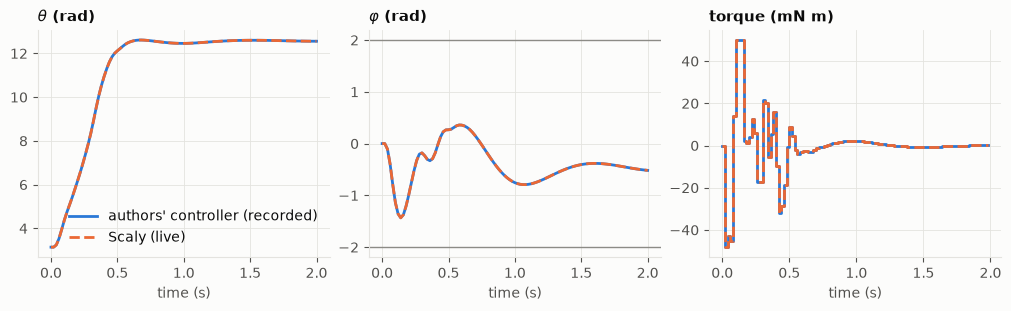

In [4]:
P_live = model.terminal_weight(z)
opti.reset()
t0 = time.perf_counter()
live = pr.lockstep(lambda x0, xg, ug, sg: opti.solve(x0, xg, ug, sg, z, P_live), lambda x0, u: model.rollout(z, x0, u), pr.SYSTEMS["sys3"])
print(f"100 steps in {time.perf_counter() - t0:.2f} s; cost {live['cost']:.3f} (theirs {ref['cost']:.3f}), settles at step {live['settle_step']} (theirs {ref['settle_step']})")
t = pr.DT * np.arange(101)
fig, axes = plt.subplots(1, 3, figsize=(10, 3.0))
for ax, (i, label) in zip(axes[:2], [(0, r"$\theta$ (rad)"), (1, r"$\varphi$ (rad)")]):
  ax.plot(t, np.array(ref["states"])[:, i], label="authors' controller (recorded)")
  ax.plot(t, live["states"][:, i], "--", label="Scaly (live)")
  ax.set_xlabel("time (s)")
  ax.set_title(label)
axes[1].axhline(2.0, color=plotstyle.NEUTRAL, lw=1)
axes[1].axhline(-2.0, color=plotstyle.NEUTRAL, lw=1)
axes[2].step(t[:-1], 1e3 * np.array(ref["applied"]), where="post")
axes[2].step(t[:-1], 1e3 * live["applied"], "--", where="post")
axes[2].set_title("torque (mN m)")
axes[2].set_xlabel("time (s)")
axes[0].legend(loc="lower right")
plt.show()

The pendulum swings past upright to $4\pi$ before it settles, because each torque acts one period
late. Solving from the measurement and applying the torque at once removes the extra revolution. The
same controller then costs 200 instead of 326, though it still takes until step 24 to settle within
10 degrees. The adaptation grid below runs both loops.

## Replay: the same 100 problems in every implementation

`compare.py replay` hands every implementation the 100 OCPs of the recorded episode, each with its
recorded starting point, in three fresh processes, and keeps the fastest solve of each instance.
The first instance is left out of the timings, because CasADi builds its solver on the first solve;
the C++ drivers make a warm-up solve instead. IPOPT comes in two builds here, the one in CasADi's 3.7.0 wheel
(3.14.11, MUMPS 5.4.1) and Scaly's vendored one (3.14.19, MUMPS 5.8.2, METIS). They are marked in
the names; laOPT and Scaly are each run against both.

In [5]:
replay = load("replay.json")
LABELS = {
  "casadi-python-published": "CasADi Python, as published",
  "casadi-python-expand": "CasADi Python, expand",
  "casadi-python-jit": "CasADi Python, jit",
  "casadi-cpp-published": "CasADi C++, as published",
  "casadi-cpp-expand": "CasADi C++, expand",
  "casadi-cpp-jit": "CasADi C++, jit",
  "laopt-ipopt": "laOPT IPOPT",
  "laopt-ipopt-scalybuild": "laOPT IPOPT (Scaly's IPOPT)",
  "laopt-sqp": "laOPT SQP-PIQP, as published",
  "scaly-opti-ipopt": "Scaly, Opti form, IPOPT",
  "scaly-opti-ipopt-casadibuild": "Scaly, Opti form (CasADi's IPOPT)",
  "scaly-laopt-ipopt": "Scaly, laOPT form, IPOPT",
  "scaly-laopt-sqp": "Scaly, laOPT form, SQP-PIQP",
}
for method in ("neural", "equation"):
  print(f"\n{method}: median / mean / p95 solve ms, mean iterations (same as the reference), converged, max |du| vs the reference")
  for impl, label in LABELS.items():
    row = replay.get(f"{impl}:{method}")
    if row is None or "failed" in row:
      print(f"  {label:36s} {'missing' if row is None else 'failed'}")
      continue
    ms = np.array(row["solve_ms"])
    print(
      f"  {label:36s} {np.median(ms):7.2f} {ms.mean():7.2f} {np.percentile(ms, 95):7.2f}   {np.mean(row['iter']):5.2f} ({row['iter_equal_reference']:3d})"
      f"   {sum(row['converged']):3d}/100   {row['max_du_vs_reference']:.1e}"
    )


neural: median / mean / p95 solve ms, mean iterations (same as the reference), converged, max |du| vs the reference
  CasADi Python, as published            17.45   17.61   23.80   13.76 (100)   100/100   0.0e+00
  CasADi Python, expand                  27.95   27.84   35.76   13.76 (100)   100/100   6.6e-16
  CasADi Python, jit                      8.93    9.06   11.51   13.76 (100)   100/100   0.0e+00
  CasADi C++, as published               15.13   16.07   20.30   13.76 (100)   100/100   0.0e+00
  CasADi C++, expand                     27.93   27.81   35.69   13.76 (100)   100/100   6.6e-16
  CasADi C++, jit                         8.93    9.03   11.52   13.76 (100)   100/100   0.0e+00
  laOPT IPOPT                            36.14   37.12   46.65   11.31 (  2)   100/100   2.7e-07
  laOPT IPOPT (Scaly's IPOPT)            32.56   33.43   41.69   11.31 (  2)   100/100   2.7e-07
  laOPT SQP-PIQP, as published            1.57    2.00    4.68    6.30 (  0)    94/100   1.3e-02
  Scaly, O

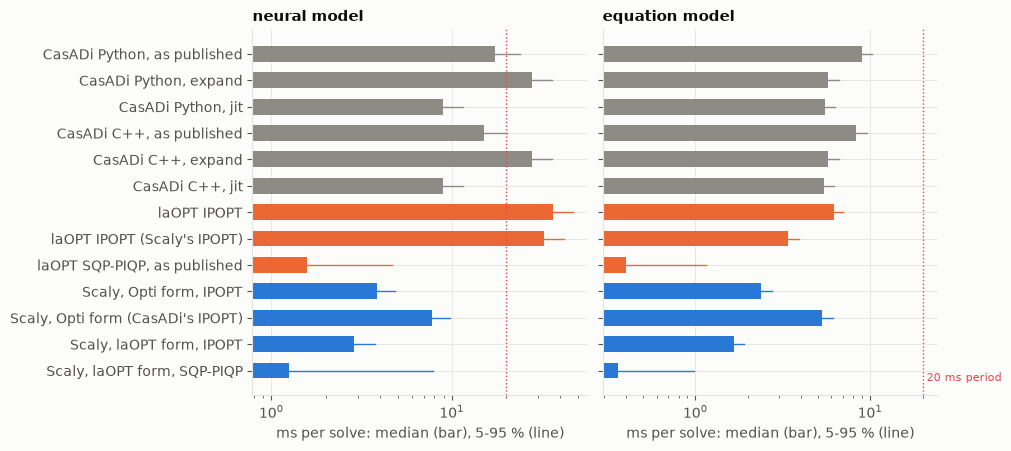

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.4), sharey=True)
order = list(LABELS)
for ax, method in zip(axes, ("neural", "equation")):
  y, meds, colors = [], [], []
  for i, impl in enumerate(order):
    row = replay.get(f"{impl}:{method}")
    if row is None or "failed" in row:
      continue
    ms = np.array(row["solve_ms"])
    y.append(i)
    meds.append(np.median(ms))
    colors.append(plotstyle.BLUE if impl.startswith("scaly") else plotstyle.ORANGE if impl.startswith("laopt") else plotstyle.NEUTRAL)
    ax.plot([np.percentile(ms, 5), np.percentile(ms, 95)], [i, i], color=colors[-1], lw=1)
  ax.barh(y, meds, color=colors, height=0.6)
  ax.set_xscale("log")
  ax.set_title(f"{method} model")
  ax.set_xlabel("ms per solve: median (bar), 5-95 % (line)")
  ax.axvline(20, color=plotstyle.RED, lw=1, ls=":")
axes[0].set_yticks(range(len(order)), [LABELS[k] for k in order])
axes[0].invert_yaxis()
axes[1].text(20, len(order) - 0.5, " 20 ms period", color=plotstyle.RED, fontsize=8, va="bottom")
plt.show()

Grey is CasADi, orange laOPT, blue Scaly; every IPOPT row solved all 100 problems to the same
solutions. What the rows say:

- **Same NLP, same solver, same iterations.** Scaly's Opti form takes CasADi's iteration count on every
  instance, both models. Its median solve is 3.8 ms against 17.5 ms for the authors' controller as
  published (MX, interpreted) and 8.9 ms with CasADi's `jit`, the fastest CasADi variant on the neural
  model. `expand` (SX, interpreted) is slower there, 28 ms, and faster on the analytic model.
- **The IPOPT build is half of it.** Run against CasADi's wheel IPOPT through the loader, Scaly's
  generated solver takes 7.7 ms. The oracles and the glue account for 8.9 against 7.7 ms, the IPOPT
  build for 7.7 against 3.8 ms. laOPT shows the same build effect on the analytic model (6.2 against
  3.4 ms).
- **laOPT's IPOPT is the slowest on the network**, 36 ms. Its automatic differentiation of the
  decoder's second derivatives costs about 3 ms per iteration. Its SQP needs only the objective's
  Hessian and is the fastest on the neural model, 1.6 ms, converging on 94 of 100 problems within its
  15 iterations.
- **Scaly's SQP converges on fewer**, 88 of 100 on the neural model and 97 on the analytic one. It
  fails on the swing-up's first problems, where the objective's own Hessian is indefinite (the terminal
  weight on $(2\sin(\theta/2))^2$ near $\theta = \pi$). Its convexification first damps curvature normal
  to the constraints, escalating to $10^9 A^\top A$, then shifts the diagonal by up to $1.8\cdot10^6$,
  and PIQP does not solve the resulting QP (`todo.md` CS-19). With the exact Hessian it converges on 95.
- The laOPT form takes laOPT's iteration count on 99 of 100 analytic-model problems and 67 of 100
  neural ones, with solutions within $3.5\cdot10^{-7}$: laOPT also passes IPOPT six unbounded rows per
  node, which the mirror leaves out.

## The adaptation study

The paper's figure 8: for each of three pendulums, $z$ from contexts of 1, 20, 50 and 100 steps
(five context experiments each, different random torques), and the equation-based controller with
the true plant parameters for reference. The authors' controller and Scaly's run the same
lockstep episodes; the grid runs with the authors' delayed loop and without it. The paper's own
numbers (`datasets/furuta_mpc/all experiments/cnp_summary_by_context.csv`, real-time runs from
June 2026) are drawn as crosses.

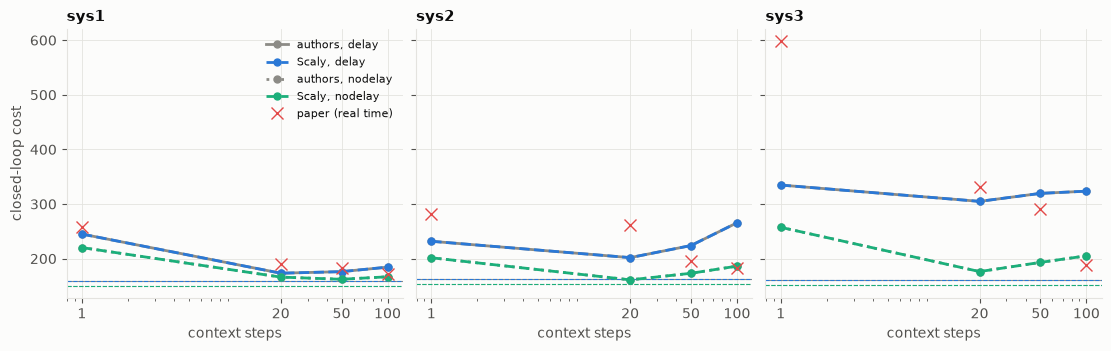

63 episodes: cost agrees to 5.8e-06 relative, settling step equal in 63
mean solve: authors' 17.42 ms, Scaly 3.69 ms; first solve after a new z: authors' 38 ms (Opti rebuilds its solver), Scaly 8.2 ms (the terminal weight and one solve)


In [7]:
PAPER = {  # cnp_summary_by_context.csv: mean closed-loop cost
  "sys1": {1: 257.601, 20: 189.936, 50: 182.477, 100: 172.575, "eq": 191.312},
  "sys2": {1: 281.434, 20: 261.157, 50: 195.709, 100: 183.283, "eq": 185.789},
  "sys3": {1: 597.615, 20: 331.604, 50: 290.12, 100: 188.615, "eq": 182.131},
}
grids = {(impl, tag): load(f"grid_{impl}_{tag}.json") for impl in ("casadi-python-published", "scaly-opti-ipopt") for tag in ("delay", "nodelay")}
CTX = [1, 20, 50, 100]


def cost_table(doc):
  out = {}
  for r in doc["rows"]:
    out.setdefault((r["system"], r["method"], r["ctx"]), []).append(r["cost"])
  return out


fig, axes = plt.subplots(1, 3, figsize=(11, 3.4), sharey=True)
for ax, system in zip(axes, ("sys1", "sys2", "sys3")):
  for (impl, tag), color, style in (
    (("casadi-python-published", "delay"), plotstyle.NEUTRAL, "-"),
    (("scaly-opti-ipopt", "delay"), plotstyle.BLUE, "--"),
    (("casadi-python-published", "nodelay"), plotstyle.NEUTRAL, ":"),
    (("scaly-opti-ipopt", "nodelay"), plotstyle.AQUA, "--"),
  ):
    table = cost_table(grids[(impl, tag)])
    mean = [np.mean(table[(system, "neural", c)]) for c in CTX]
    ax.plot(CTX, mean, style, marker="o", color=color, label=f"{'authors' if impl.startswith('casadi') else 'Scaly'}, {tag}")
    ax.axhline(table[(system, "equation", 0)][0], color=color, lw=0.8, ls=style)
  ax.plot(CTX, [PAPER[system][c] for c in CTX], "x", color=plotstyle.RED, ms=8, label="paper (real time)")
  ax.set_xscale("log")
  ax.set_xticks(CTX, [str(c) for c in CTX])
  ax.set_title(system)
  ax.set_xlabel("context steps")
axes[0].set_ylabel("closed-loop cost")
axes[0].legend(fontsize=8)
plt.show()

a, b = grids[("casadi-python-published", "delay")]["rows"], grids[("scaly-opti-ipopt", "delay")]["rows"]
print(f"{len(a)} episodes: cost agrees to {max(abs(x['cost'] - y['cost']) / x['cost'] for x, y in zip(a, b)):.1e} relative, "
      f"settling step equal in {sum(x['settle_step'] == y['settle_step'] for x, y in zip(a, b))}")
print(f"mean solve: authors' {np.mean([x['solve_ms_mean'] for x in a]):.2f} ms, Scaly {np.mean([y['solve_ms_mean'] for y in b]):.2f} ms; "
      f"first solve after a new z: authors' {1e3 * np.mean([x['first_solve_s'] for x in a]):.0f} ms (Opti rebuilds its solver), "
      f"Scaly {1e3 * np.mean([y['first_solve_s'] + y['build_s'] for y in b]):.1f} ms (the terminal weight and one solve)")

The authors' lines lie under Scaly's, since all 63 episodes of each grid agree. Two things about the
numbers themselves. With the authors' delayed loop, system 3's neural controller overshoots to
$4\pi$ before it settles, and its cost stays near 320 whatever the context; without the delay it comes
down to 176-205 and settles in about 12 steps, near the paper's 188 at 100 steps. The paper's crosses
are real-time runs from June 2026, and the release's own real-time deploy lands near the delayed grid
(next section). The context-size trend is not monotone in either loop.

Scaly passes $z$ as a runtime parameter, so a new latent code costs the terminal weight's Riccati solve
(3 ms) and one solve. Opti bakes $z$ into its graph, so the authors' controller rebuilds its problem
and its first solve builds the NLP solver, 38 ms in all once CasADi is warm.

## Real time

The authors' `scripts/run_qube_server.py` integrates the plant in its own process at 4 kHz on
wall-clock time and streams the state at 500 Hz; a client answers with torques. Their C++ clients
solve as fast as they can from the newest state, warm-started from the previous solution, with no
delay compensation; the laOPT ones wait until 4.3 ms after a solve started before sending. Their
Python deploy paces itself at 20 ms with the delay compensation. `realtime_scaly.py` is a client like
their C++ ones. Each agent ran three times for 1 s; the table has the median run.

In [8]:
rt_up = load("realtime_upstream.json")["agents"]
rt_sc = load("realtime_scaly.json")


def median_run(runs):
  return sorted(runs, key=lambda r: r["cost"])[len(runs) // 2]


print(f"{'agent':34s} {'cost':>9s} {'settles (s)':>12s} {'solves':>7s} {'mean ms':>8s}  converged")
for name, agent in rt_up.items():
  r = median_run(agent["runs"])
  print(f"{name:34s} {r['cost']:9.1f} {str(r['settling_time']):>12s} {r['n_solves']:7d} {r['solve_ms']['mean']:8.2f}  {r['converged_fraction']:.2f}")
groups = {}
for r in rt_sc:
  if "failed" not in r:
    groups.setdefault((r["implementation"], r["method"]), []).append(r)
for (impl, method), runs in groups.items():
  r = median_run(runs)
  print(f"{impl + ' ' + method:34s} {r['cost']:9.1f} {str(r['settle_time']):>12s} {r['solves']:7d} {r['solve_ms_mean']:8.2f}  {r['converged'] / r['solves']:.2f}")

agent                                   cost  settles (s)  solves  mean ms  converged
cpp-np-laopt-sqp                       202.6          0.2     201     1.52  0.93
cpp-np-laopt-ipopt                    5308.9         None       9   120.88  0.44
cpp-np-laopt-ipopt-scaly              8749.3         None      10   107.23  0.40
cpp-np-casadi                        33643.2         None      25    45.15  0.56
cpp-eq-laopt-sqp                       158.1         0.24     196     0.62  0.98
cpp-eq-laopt-ipopt                     285.9          0.6     138     7.21  1.00
cpp-eq-laopt-ipopt-scaly               152.0         0.24     222     3.84  1.00
cpp-eq-casadi                        39602.6         None      52    20.65  0.73
py-np-casadi                           635.4         None      41    22.02  1.00
py-eq-casadi                           162.4         0.24      45     9.94  1.00
scaly-laopt-ipopt neural               157.1         0.26     363     2.69  1.00
scaly-laopt-sqp neural 

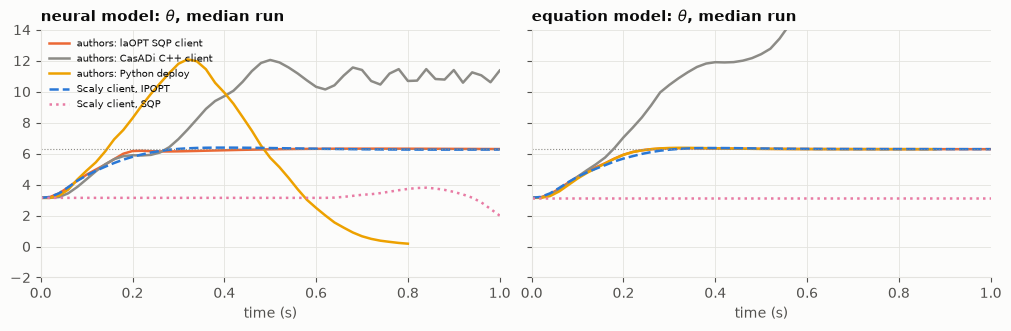

In [9]:
SHOWN = {  # agent -> (label, colour, style)
  "laopt-sqp": ("authors: laOPT SQP client", plotstyle.ORANGE, "-"),
  "casadi": ("authors: CasADi C++ client", plotstyle.NEUTRAL, "-"),
  "py-casadi": ("authors: Python deploy", plotstyle.YELLOW, "-"),
  "scaly-laopt-ipopt": ("Scaly client, IPOPT", plotstyle.BLUE, "--"),
  "scaly-laopt-sqp": ("Scaly client, SQP", plotstyle.MAGENTA, ":"),
}
fig, axes = plt.subplots(1, 2, figsize=(10, 3.2), sharey=True)
for ax, method, tag in ((axes[0], "neural", "np"), (axes[1], "equation", "eq")):
  series = {
    "laopt-sqp": rt_up[f"cpp-{tag}-laopt-sqp"]["runs"],
    "casadi": rt_up[f"cpp-{tag}-casadi"]["runs"],
    "py-casadi": rt_up[f"py-{tag}-casadi"]["runs"],
    "scaly-laopt-ipopt": groups[("scaly-laopt-ipopt", method)],
    "scaly-laopt-sqp": groups[("scaly-laopt-sqp", method)],
  }
  for key, runs in series.items():
    label, color, style = SHOWN[key]
    x = np.array(median_run(runs)["states"])[:, 0]
    t = pr.DT * np.arange(len(x))
    keep = t <= 1.0
    ax.plot(t[keep], x[keep], style, color=color, lw=1.8, label=label)
  ax.axhline(2 * np.pi, color=plotstyle.NEUTRAL, lw=0.8, ls=":")
  ax.set_ylim(-2, 14)
  ax.set_xlim(0, 1.0)
  ax.set_title(rf"{method} model: $\theta$, median run")
  ax.set_xlabel("time (s)")
axes[0].legend(fontsize=7, loc="upper left")
plt.show()

On this machine the authors' laOPT SQP clients are the ones of theirs that work at full speed: 200
solves in the 1 s run, upright by 0.2 s. Their C++ CasADi clients do not swing up. With the IPOPT in
CasADi's wheel their solves take 20-40 ms on average and up to 70, they have no delay compensation, and
an unconverged iterate is applied as is: Opti poses the torque bound as a row, which an IPOPT iterate
may violate (they sent torques up to 1.68 N m against a bound of 0.05). The laOPT IPOPT clients fail for the same
reason on the neural model (over 100 ms per solve) and swing up on the analytic one. The Python deploy
swings up with its delay-compensated loop, overshooting as in the lockstep episodes, in 1 of 3 runs
within the 1 s.

Scaly's IPOPT clients, the same generated solvers as in the replays, run at 250-500 solves per second
and swing up in every run. Scaly's SQP client does not. Like the laOPT clients it repeats its first
solve until it converges before sending a torque, and from the hanging state that takes it 0.5 to 8 s
(CS-19), against 5 ms for laOPT's SQP; the pendulum swings freely meanwhile and the controller never
recovers. The variant that waits 4.3 ms per solve, as the laOPT clients do, fares no better.

## Rerunning the baselines

With `RUN_BASELINES = True` this runs `baseline/setup.sh`, then the whole study: the reference
episodes, the replays, the episodes, the grids and the real-time runs, each timed process on a quiet
machine. Everything lands in `results/`.

In [10]:
if RUN_BASELINES:
  subprocess.run([str(HERE / "baseline" / "setup.sh")], check=True)
  subprocess.run([sys.executable, str(HERE / "compare.py"), "all", "--force"], check=True)